# **PyTorch workflow**

Let's explore an example PyTorch end-to-end workflow

`data (prepare and load) -> build model -> fitting the model to data (training) -> making predictions and evaluating a model (inference) -> saving and loading a model -> putting it all together`

In [2]:
import torch
from torch import nn    # nn contains all of PyTorch's building blocks for neural networks
import matplotlib.pyplot as plt

## 1. Data (preparing and loading)

Data can be almost anything.
* Excel spreadsheets
* Images
* Videos
* Audio
* Text
* etc.

Machine learning is a game of two parts:
1. Get data into a numerical representation
2. Build a model to learn patterns in that numerical representation.

To showcase this, let's create some *known* data using the lineaer regression formula.

We'll use a linear regression formula to make a straight line with known **parameters**

In [ ]:
# Create *known* parameters
weight = 0.7
bias = 0.3

# Create
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]


(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]),
 50,
 50)

In [4]:
len(X), len(y)

(50, 50)

### Splitting data into training and test sets

In [7]:
# Create a train/test split
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

How might we better visualiza our data?

In [8]:
def plot_predictions(train_data = X_train, train_labels = y_train, test_data = X_test, test_labels = y_test, predictions = None):
    """
    Plots training data, test data and compares predictions.
    """
    plt.figure(figsize=(10, 7))

    # Plot training data in blue
    plt.scatter(train_data, train_labels, c = "b", s = 4, label = "Training data")

    # Plot test data in green
    plt.scatter(test_data, test_labels, c = "g", s = 4, label = "Testing data")

    if predictions is not None:
        plt.scatter(test_data, predictions, c = "r", s = 4, label = "Predictions")

    plt.legend(prop={"size": 14})

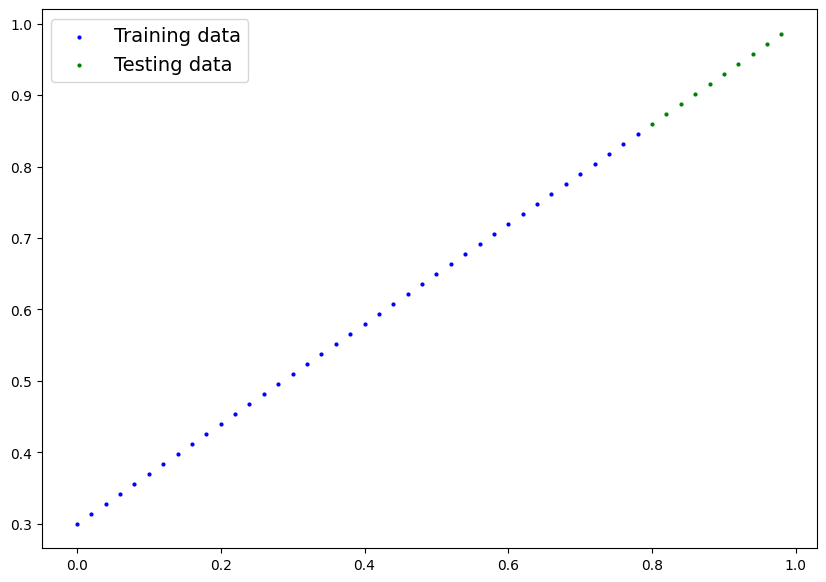

In [10]:
plot_predictions()